# Exercise Sheet 5

In [46]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thursday October 3, 2024

@authors: Elena Raponi, Lennard Froma, Ivan Olarte-Rodriguez (partially inspired by Peter Frazier)

"""

# Import the Libraries

# Typical Libraries for Numerical Processing
import numpy as np
from matplotlib import pyplot as plt

# Scikit Learn Libraries (For handling basic Regression Processes)
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern,RBF, ConstantKernel as C
from typing import Callable


In the following block there are listed four different functions. Run this block in order to load the functions into the main module. These functions are then going to be switched to perform different approximations with the regressors.


In this section of the exercise you will now work with the acquisition functions. In the framework of Bayesian Optimization, you first need to build a surrogate model through a Gaussian Process Regression. With the information of the regressor, then you need to decide the next point of the decision space to pick. This decision process is evaluated through an acquisition function which points the "next most interesting point" according to some metric embedded into the acquistion function.

### Preliminaries:

[[0.12 0.18]
 [0.13 0.88]
 [0.15 0.25]
 [0.19 0.11]
 [0.55 0.62]
 [0.58 0.71]
 [0.63 0.59]
 [0.84 0.76]
 [0.88 0.83]
 [0.92 0.79]]


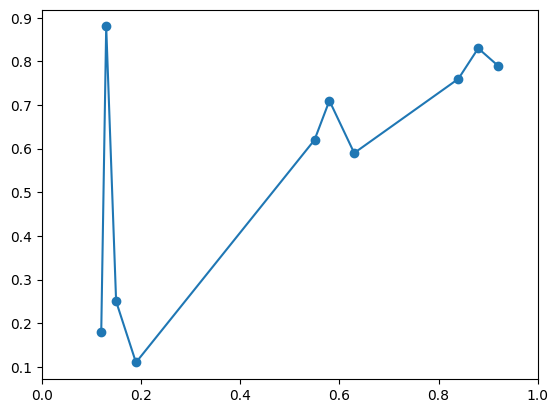

In [47]:
import os.path
import math

# Scikit Learn Libraries (For handling basic Regression Processes)
# Read in data from a file.  Download this from the BrightSpace  before you start.  
# If you forget to do this, the cell will generate the data for you, but small
# differences in random number generators might lead to different training data,
# which may make the lab harder to do.
filename = 'lab5_data.csv'

# If data doesn't exist, generate it
if not os.path.exists(filename):
    np.random.seed(1)
    train_x = np.sort(np.random.rand(10)) # 10 points, uniformly distributed between 0 and 1
    train_y = [math.sin(x * (2 * math.pi)) + 0.0 * np.random.randn() for x in train_x]
    data = np.transpose([train_x,train_y])
    np.savetxt(filename,data)

# Read in data from a file.  
data = np.loadtxt(filename)
train_x = data[:,0] # First column of the data
train_y = data[:,1] # Second column of the data
plt.xlim(0,1)
plt.plot(train_x, train_y,'o-')
print(data)

In [48]:
def plot_prediction(train_x:np.ndarray, 
                    train_y:np.ndarray, 
                    gpr:GaussianProcessRegressor):
    m = []
    lb = []
    ub = []

    train_x = train_x.reshape((-1,1))
    train_y = train_y.reshape((-1,1))

    # Fit the GPR
    gpr.fit(train_x,train_y)

    x = np.linspace(0,1,100)
    for test_x in x:
        pred_mean, pred_std = gpr.predict(np.array([test_x]).reshape(-1,1),return_std=True)
        m.append(pred_mean)
    
        # Calculate the posterior standard deviation
        if pred_std<0:
            print('Posterior standard deviation is negative ({:e}) at x={}, rounding up to 0'.format(pred_std, test_x))
            pred_std = 0
    
        s = pred_std.copy() 
        
        lb.append(pred_mean-1.96*s)
        ub.append(pred_mean+1.96*s)
    
    m = np.array(m).ravel()
    lb = np.array(lb).ravel()
    ub = np.array(ub).ravel()

    _, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(train_x,train_y,'ko')
    ax.plot(x,m.ravel(),'k',linewidth=0.5)
    ax.fill_between(x,lb,ub)
    ax.legend(['Observed Data', 'Mean', 'Confidence'])

### Exercise 1: The Expected Improvement Function
The Expected Improvement is the most used acquisition function in most Bayesian Optimization frameworks. The main advantage of this function is that it has embedded both exploration and exploitation balance and can be computed in a closed form (without expensive numerical computations).

Write a function that calculates the expected improvement given the posterior mean (m), posterior variance (v),
and the value of the best point observed (best_y), for settings where we are maximizing.
You can use either of these two equivalent formulas:

$$\mathrm{EI}_n(x) = \sigma_n(x) \varphi\left(\frac{\Delta_n(x)}{\sigma_n(x)}\right) + \Delta_n \Phi\left(\frac{\Delta_n(x)}{\sigma_n(x)}\right)$$


$$\mathrm{EI}_n(x) = [\Delta_n(x)]^+ + \sigma_n(x) \varphi\left(\frac{\Delta_n(x)}{\sigma_n(x)}\right) - |\Delta_n|\Phi\left(\frac{-|\Delta_n(x)|}{\sigma_n(x)}\right)$$
where
- $\mu_n(x)$ is the posterior mean at $x$
- $\sigma_n(x)$ is the posterior standard deviation at $x$
- $\varphi$ is the density of the standard normal distribution (i.e., normal distribution with mean 0 and variance 1)
- $\Phi$ is the cdf of the standard normal distribution
- $\Delta_n(x)$ is $\mu_n(x) - f^*_n$ when we are maximizing and $f^*_n - \mu_n(x)$ when we are minimizing, where $f^*_n$ is the value of the best point observed so far


Your code may need to handle very small variances as a special case to avoid dividing by 0.
The EI for a variance of 0 is max(0,m-best_y).  You may also need to handle small negative variances 
--- treat them as 0.

You can use `scipy.stats.norm.pdf` and `scipy.stats.norm.cdf`

In [ ]:
from scipy.stats import norm


def EI(m:float,v:float,best_y:float, minimization:bool = False):
    
    '''
    This is a base Expected Improvement function. The inputs of this function are:
    - m: The posterior mean
    - v: The posterior variance
    - best_y: The sampled best value of the objective
    - minimization: A boolean handle to determine if the objective is minimized or maximized
    '''
    

       
        
    ##### TODO: Enter your code here:

    if minimization:
        delta = best_y - m
    else:
        delta =  m - best_y
        
    s = np.sqrt(v)
    z = delta/s if s >1e-08 else delta
    ret = max(0,delta)
    ret += s * norm.pdf(z, loc=0) 
    ret -= abs(delta)*norm.cdf(-1*abs(z))
    
    return ret
    
    ##### --------------- END OF CODE INPUT -----------------------



# Test your code!!!
print(EI(1,1e-100,0))
print(EI(2,1,0))
print(EI(0,2,2))
print(EI(0,10,2))


1.0
2.0084907026168297
0.05025454166001228
0.5057938380690186


### Other Acquistion Functions
In the following block you will find the definition of other acquisition functions. Notice the inputs are mostly the same from before except for the last parameters.

In [50]:
def ucb(m:float,v:float,best_y:float, psi=1.96):
    """The upper confidence acquisition function."""
    if v <= 0:
        return max(0,m-best_y)

    return m + psi * np.sqrt(v)

def lcb(m:float,v:float,best_y:float, psi=1.96):
    """The lower confidence acquisition function."""
    if v <= 0:
        return max(0,m-best_y)
    
    return m - psi * np.sqrt(v)

def poi(m:float,v:float,best_y:float, psi=0.):
    """Return the probability of improvement.
    
    Arguments
    psi   -- A parameter that controls exploration.
    """
    if v <= 0:
        return max(0,m-best_y)
    
    return norm.cdf((m - best_y - psi) / np.sqrt(v))

### Exercise 2: Plotting an acquisition function
Define a function `plot_acq` which uses the function defined above to compute it. In order to compute the variance, first use `GPR.fit(train_x,train_y)` to fit the model and then `GPR.predict(test_x, return_std=True)` to get the prediction of the mean and the prediction of the variance, respectively.


[0.18 0.88 0.25 0.11 0.62 0.71 0.59 0.76 0.83 0.79]
0.88


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better valu

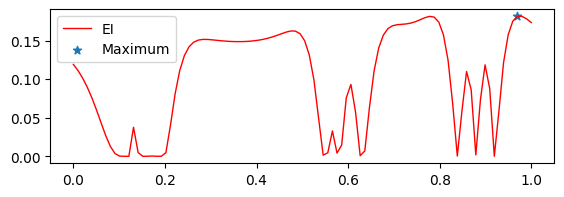

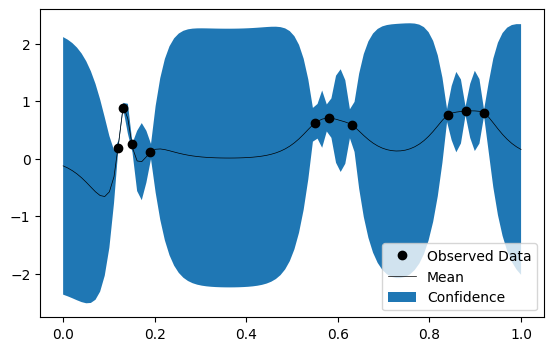

In [ ]:

kernel = C(constant_value=0.2)*Matern(length_scale=2,
               length_scale_bounds=(5e-02,9e-01),
               nu=1.5)
# kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
sampleGPR = GaussianProcessRegressor(kernel=kernel,
                                    n_restarts_optimizer=10)

sampleGPR.fit(X=train_x.reshape((-1,1)),
                             y=train_y.reshape((-1,1)))

# Using any acquistion function, we plot the posterior
def plot_acq(train_x:np.ndarray,
            train_y:np.ndarray,
            best_y:float, 
            acq_fun:Callable=EI,
            GPR:GaussianProcessRegressor=sampleGPR,
            acq_fun_name:str = "EI",
            plot_max:bool = True):
    
    if train_x.shape[0] == train_x.size:
        train_x = train_x.reshape((-1,1))

    if train_y.shape[0] == train_y.size:
        train_y = train_y.reshape((-1,1))

    best_y:np.ndarray = np.array([best_y]).reshape((-1,1))

    ##### TODO:  Enter your code here:

    # fit
    GPR.fit(train_x,train_y)

    acq_cum = [] # This list is to store the evaluated aquisition_function
    
    # This array is meant to sample equidistant points and evaluate the acquistion function
    # At those points
    x = np.linspace(0,1,100).reshape((-1,1)) 

    for test_x in x:
        pred_mean, pred_std = GPR.predict(test_x.reshape((-1,1)), 
                                                               return_std=True)
        acq = acq_fun(pred_mean.ravel(),np.power(pred_std.ravel(),2),best_y.ravel())
        
        acq_cum.append(acq)
    
    ##### --------------- END OF CODE INPUT -----------------------
    fig, ax = plt.subplots(figsize=(6.5, 2))
    ax.plot(x,acq_cum,'r',linewidth=1)

    if plot_max:
        xmax = x[np.argmax(acq_cum)]
        ymax = max(acq_cum)
        ax.scatter(xmax, ymax, marker="*")
        ax.legend([acq_fun_name, "Maximum"])
    else:
        ax.legend([acq_fun_name])

best_y = max(train_y)
print(train_y)
print(best_y)


plot_acq(train_x, train_y,best_y=best_y,GPR = sampleGPR)
plot_prediction(train_x, train_y, gpr= sampleGPR)


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better valu

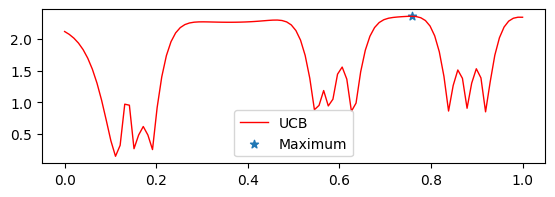

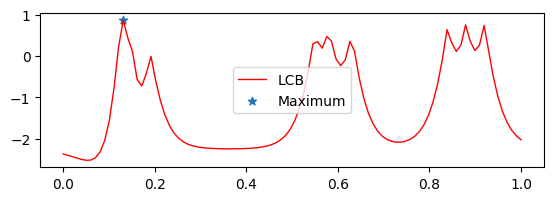

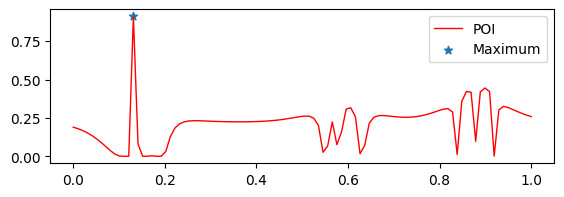

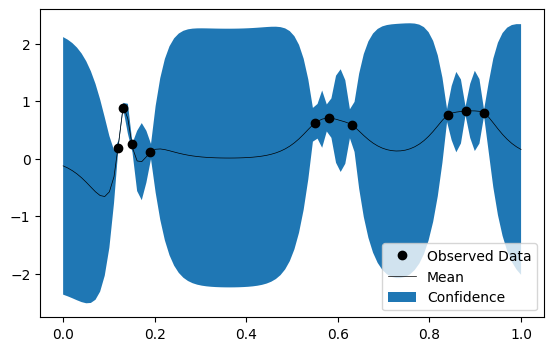

In [52]:
# Other plots
plot_acq(train_x, train_y,best_y=best_y,GPR = sampleGPR,acq_fun=ucb,acq_fun_name="UCB")
plot_acq(train_x, train_y,best_y=best_y,GPR = sampleGPR,acq_fun=lcb,acq_fun_name="LCB")
plot_acq(train_x, train_y,best_y=best_y,GPR = sampleGPR,acq_fun=poi,acq_fun_name="POI")
plot_prediction(train_x, train_y, gpr= sampleGPR)

# Exercise 3

Now you've implemented Expected Improvement (EI) we will implement the weighted EI by adding an alpha parameter making it a convex unitary transformation as follows:

$$\mathrm{EI}_n(x;\alpha) = \alpha \sigma_n(x) \varphi\left(\frac{\Delta_n(x)}{\sigma_n(x)}\right) + (1-\alpha)\Delta_n \Phi\left(\frac{\Delta_n(x)}{\sigma_n(x)}\right)$$


[[0.12 0.18]
 [0.13 0.88]
 [0.15 0.25]
 [0.19 0.11]
 [0.55 0.62]
 [0.58 0.71]
 [0.63 0.59]
 [0.84 0.76]
 [0.88 0.83]
 [0.92 0.79]]


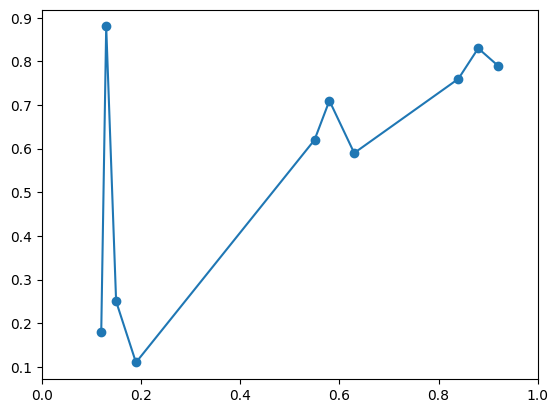

In [53]:
import os.path
import math

# Scikit Learn Libraries (For handling basic Regression Processes)
# Read in data from a file.  Download this from the BrightSpace  before you start.  
# If you forget to do this, the cell will generate the data for you, but small
# differences in random number generators might lead to different training data,
# which may make the lab harder to do.
filename = 'lab5_data.csv'

# If data doesn't exist, generate it
if not os.path.exists(filename):
    np.random.seed(1)
    train_x = np.sort(np.random.rand(10)) # 10 points, uniformly distributed between 0 and 1
    train_y = [math.sin(x * (2 * math.pi)) + 0.0 * np.random.randn() for x in train_x]
    data = np.transpose([train_x,train_y])
    np.savetxt(filename,data)

# Read in data from a file.  
data = np.loadtxt(filename)
train_x = data[:,0] # First column of the data
train_y = data[:,1] # Second column of the data
plt.xlim(0,1)
plt.plot(train_x, train_y,'o-')
print(data)

In [ ]:
from scipy.stats import norm


def WEI(m:float,v:float,best_y:float, alpha:float, minimization:bool = False):
    
    '''
    This is a base Expected Improvement function. The inputs of this function are:
    - m: The posterior mean
    - v: The posterior variance
    - best_y: The sampled best value of the objective
    - minimization: A boolean handle to determine if the objective is minimized or maximized
    '''

    if minimization:
        delta = best_y - m
    else:
        delta =  m - best_y
        
    s = np.sqrt(v)
    z = delta / s if s > 1e-08 else delta
    ret = max(0,delta)
    ret += alpha * s * norm.pdf(z, loc=0) 
    ret -= (1-alpha) * abs(delta)*norm.cdf(-1*abs(z))

    return ret
    
    ##### --------------- END OF CODE INPUT -----------------------



# Test your code!!!
alphas = [0, 0.5, 1]
for alpha in alphas:
    print(WEI(m=1,v=1e-100,best_y=0, alpha=alpha))
    print(WEI(m=2,v=1,best_y=0,alpha=alpha))
    print(WEI(m=0,v=2,best_y=2,alpha=alpha))
    print(WEI(m=0,v=10,best_y=2,alpha=alpha))


1.0
1.9544997361036416
-0.15729920705028516
-0.5270892568655381
1.0
2.004245351308415
0.02512727083000614
0.2528969190345093
1.0
2.053990966513188
0.20755374871029744
1.0328830949345567


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


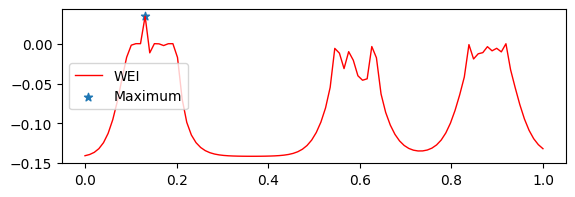

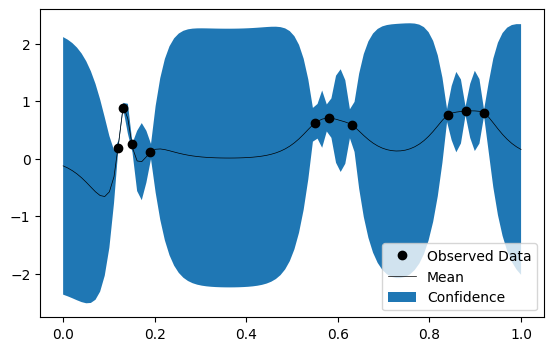

In [55]:
from functools import partial

best_y = max(train_y)
new_wei = partial(WEI,alpha=0.1)

plot_acq(train_x, train_y,best_y=best_y,GPR = sampleGPR,acq_fun=new_wei,acq_fun_name="WEI")
plot_prediction(train_x, train_y, gpr= sampleGPR)

In the following part, we will start working by implementing a full loop of a Bayesian Optimization Pipeline. In this case, we will use `BoTorch` since some of the required steps are easily called by using it. Nevertheless, you may find you ought to load too many objects as in the next block. Furthermore, to call the problems, we will use the `cocoex` modules, which let you experiment with all the COmparing COntinuous Optimizers `COCO` problems and call the suite of optimization problems therein.

### Table of the Functions in *bbob-constrained*
<!-- 
| **Number of constraints** | 1 | 3 | 9 + ⌊3n/4⌋ | 9 + ⌊3n/2⌋ | 9 + ⌊9n/2⌋ |
|----------------------------|---|---|-------------|-------------|-------------|
| **Number of active constraints** | 1 | 2 | 6 + ⌊n/2⌋ | 6 + n | 6 + 3n |

| **Objective** | **T** | **c<sub>scal</sub>** | **Function IDs** |
|----------------|-------|-----------------------|------------------|
| *f<sub>sphere</sub>* | id | 10 | 1, 2, 3, 4, 5, 6 |
| *f<sub>ellipsoid</sub>* | T<sub>osz</sub> | 10⁻⁴ | 7, 8, 9, 10, 11, 12 |
| *f<sub>linear</sub>* | id | 10 | 13, 14, 15, 16, 17, 18 |
| *f<sub>elli_rot</sub>* | T<sub>osz</sub> | 10⁻⁴ | 19, 20, 21, 22, 23, 24 |
| *f<sub>discus</sub>* | T<sub>osz</sub> | 10⁻⁴ | 25, 26, 27, 28, 29, 30 |
| *f<sub>bent_cigar</sub>* | T<sub>asy</sub><sup>0.5</sup> ∘ T<sub>osz</sub> | 10⁻⁴ | 31, 32, 33, 34, 35, 36 |
| *f<sub>diff_powers</sub>* | id | 10 | 37, 38, 39, 40, 41, 42 |
| *f<sub>rastrigin</sub>* | T<sub>asy</sub><sup>0.2</sup> ∘ T<sub>osz</sub> | 10 | 43, 44, 45, 46, 47, 48 |
| *f<sub>rast_rot</sub>* | T<sub>asy</sub><sup>0.2</sup> ∘ T<sub>osz</sub> | 10 | 49, 50, 51, 52, 53, 54 | -->

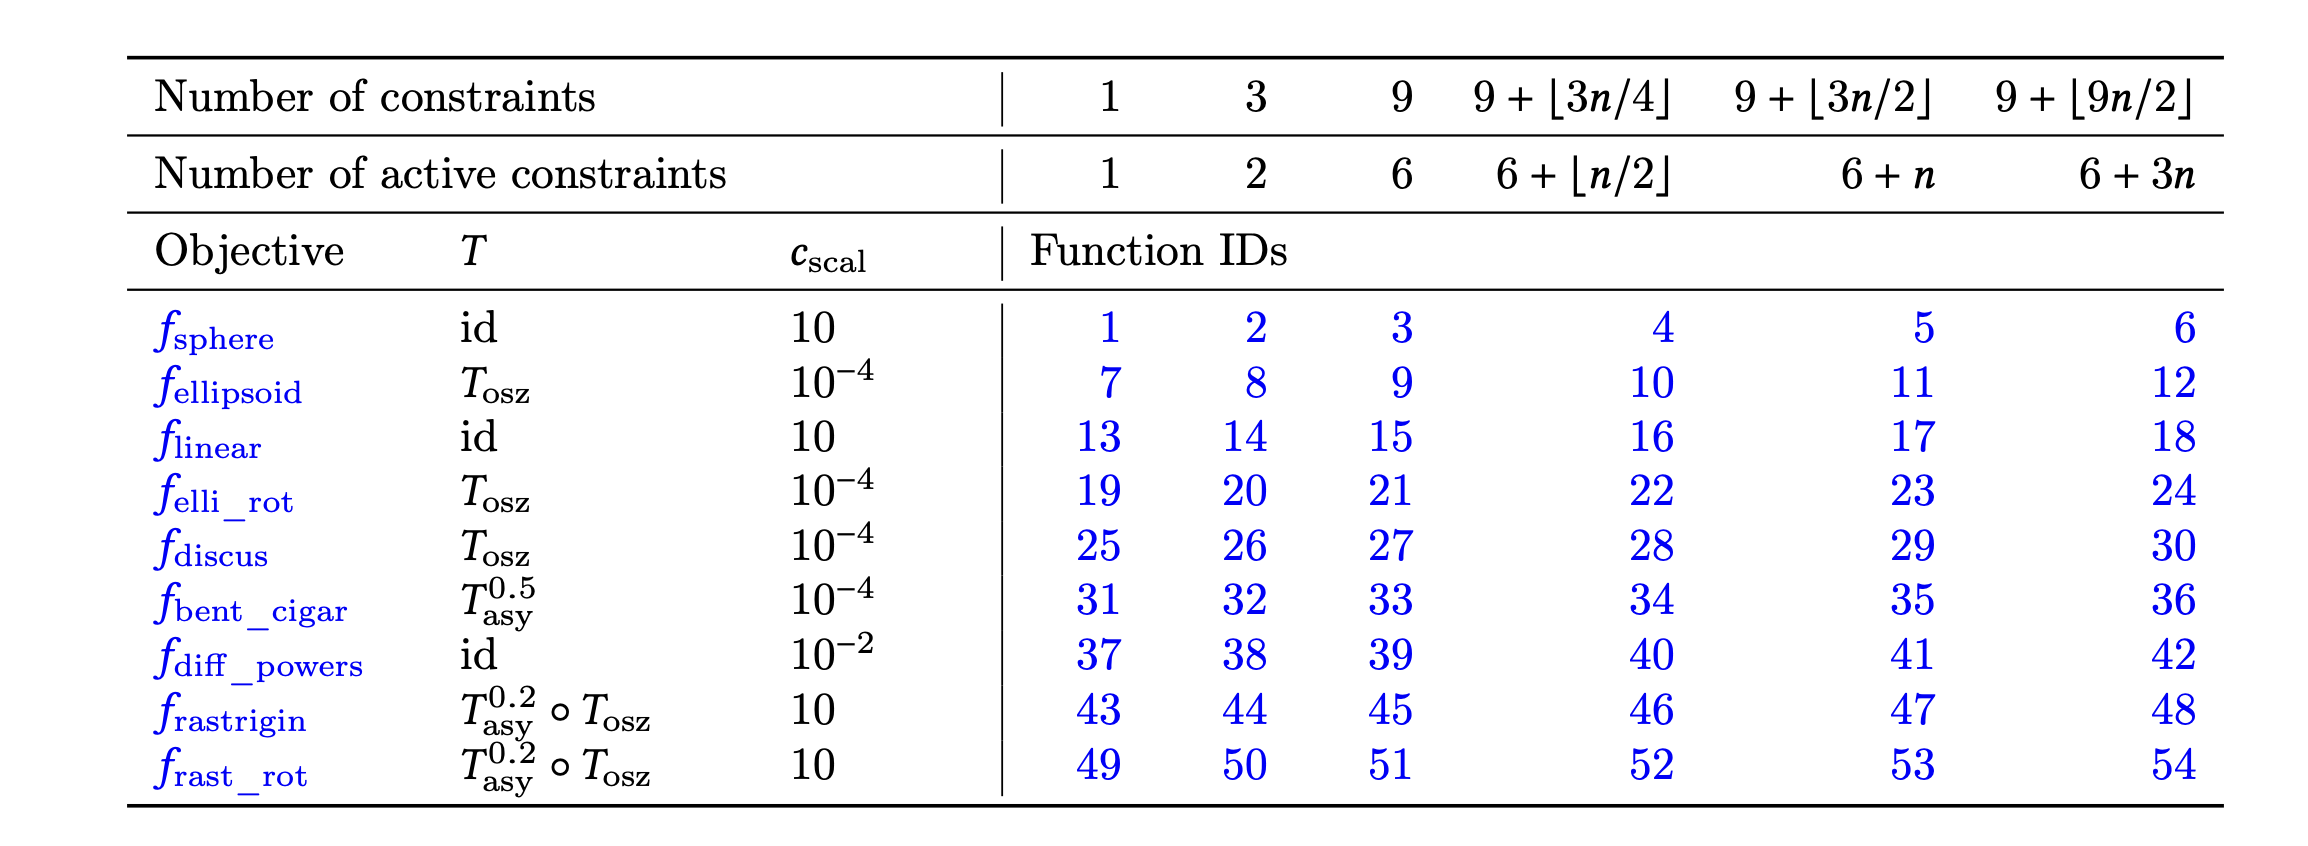
For more information check: https://numbbo.github.io/coco-doc/bbob-constrained/functions.pdf

**Table 1:** Identifiers of the *bbob-constrained* problems, where *T* is a non-linear search space transformation (described in *Non-linear transformations*) applied with each objective and *id(x) = x*. The 2-D contour plots of the first instance of each test problem can be found in the Appendix or by clicking the objective function name. Contour plots of other instances in 2-D are given [at this link](https://example.com).

In [56]:
# Imports the COCO Experimenter module
import cocoex 

# This is for calling the Problem class from cocoex. This is used for typing purposes
from cocoex import Problem

# Typing Libraries
from typing import Iterable,Union,List,Tuple,Callable, Optional

# Import numpy, warnings and torch libraries 
import numpy as np
import warnings
import torch 
from torch import Tensor, device, float64 #This is relevant for the device to be used (CPU or GPU) and the type of tensor

# Import the BoTorch Libraries
from torch.quasirandom import SobolEngine # To use in this case for the DoE step
from botorch.models.transforms.input import Normalize # This is to normalize the inputs (from 0 to 1 in each dimension)
from botorch.models.transforms.outcome import Standardize # This is to standardize the outputs (0 mean and unit variance)
from botorch.models import SingleTaskGP, ModelListGP # This is to define the GP model (Single Task or a list of GPs)
from botorch.optim import optimize_acqf # This is to optimize the acquisition function
from botorch.acquisition import AcquisitionFunction # This is the base class for the acquisition functions
from botorch.acquisition.analytic import AnalyticAcquisitionFunction # This is the base class for the analytic acquisition functions

# This is to import the Expected Improvement and the Probability of Feasibility and Cons acquisition functions
from botorch.acquisition.analytic import ExpectedImprovement, LogExpectedImprovement, LogProbabilityOfFeasibility 

# this is to import the automatic fitting method to use and 'train' the GP hyperparameters via Maximum Likelihood Estimation
from botorch.fit import fit_gpytorch_mll

# This is to call the decorator to handle the input transformations for the case of batch evaluations in Acquisition Functions
from botorch.utils.transforms import t_batch_mode_transform

# This is to import the GPyTorch libraries
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood # This is to define a Gaussian Likelihood with fixed noise (we set noise to 1e-6 for defining noise-free observations)
from gpytorch.kernels import MaternKernel, ScaleKernel,Kernel # This is to define the kernel (Matern Kernel with ARD and a scaling factor (alpha0 in the slides))
from gpytorch.means import ConstantMean, Mean # This is to define the mean function (a constant mean)
from gpytorch.constraints import Positive, GreaterThan # This is to set constraints on the hyperparameters of the GPyTorch models
from torch.distributions.normal import Normal # This is to handle the normal distribution (for the acquisition functions)
from gpytorch.mlls.sum_marginal_log_likelihood import SumMarginalLogLikelihood # This is to define the sum of the marginal log-likelihood (for ModelListGP)
from gpytorch.mlls import ExactMarginalLogLikelihood # This is to define the exact marginal log-likelihood (for SingleTaskGP)


### ===========================
### Select the suite (TO BE THE BBOB-CONSTRAINED)
### ===========================
suite_name = "bbob-constrained"
suite = cocoex.Suite('bbob-constrained','' , '' )

The following block is an example on how to instantiate one of the problems contained the `bbob-constrained` suite of `cocoexp`. In this case the algorithm `COBYLA` is used. Notice well how the 'logging' is called and how to attach the logger to the problem via the method `observe_with`.

In [57]:
## Example
### SAMPLE CODE: This code runs the optimization using the ‘ fmin_cobyla ‘ function from ‘ scipy.optimize ‘
### SAMPLE CODE: RUN IF YOU LIKE! and to compare with the Constrained Bayesian Optimizer
from scipy.optimize import fmin_cobyla as fmin

def get_constraints ( problem ) :
    """ return the constraint function from ‘ problem ‘ """
    def constraint ( x ) :
        """ constraints for ‘ fmin_cobyla ‘ where >= 0 means feasible """
        return - problem.constraint( x )
    return constraint # a function

# Generate an observer to be used in the optimization (this is the `logger` for cocoex interface)
observer = cocoex.Observer('bbob-constrained' , 'result_folder :' + fmin.__name__ )

# Call a specific problem. In this case, we call the 1st function (Sphere) in 2 dimensions and instance 1 (3 constraints)
problem:Problem = suite.get_problem_by_function_dimension_instance(function=2, dimension=2, instance=1)

# Add the observer to the problem
problem.observe_with( observer )

# Run the optimization with COBYLA
x_min = fmin(problem , problem.initial_solution , get_constraints( problem ), 
    rhobeg =2 , rhoend =1e-08 , maxfun =1e02, disp=2) # next step : increase maxfun to 1 e3 ...

print("x_min = ", x_min)
print("f(x_min) = ", problem(x_min))
print("g(x_min) = ", problem.constraint(x_min))


x_min = COCO INFO: Results will be output to folder exdata/fmin_cobyla-0005
 [1.2072 0.448 ]
f(x_min) =  -2024.8071808
g(x_min) =  [-4.17287013e-12 -8.88341339e-13 -6.92830995e+03]

   Normal return from subroutine COBYLA

   NFVALS =   25   F =-2.024807E+03    MAXCV = 0.000000E+00
   X = 1.207200E+00   4.480000E-01


In [58]:
# A copy of the problem to be used in the Bayesian Optimizer
obs_problem = suite.get_problem_by_function_dimension_instance(function=2, dimension=2, instance=1)

In [59]:
### ===========================
### Attach an Observer
### ===========================

observer_unconstrained = cocoex.Observer('bbob' , 'result_folder :' + "BO" )
obs_problem.observe_with( observer_unconstrained )

COCO INFO: Results will be output to folder exdata/BO-0003


<cocoex.interface.Problem(), id='bbob-constrained_f002_i01_d02'>

# Exercise: Completing the `__call__` Function of the Bayesian Optimizer

## Objective

In this exercise, you will complete the missing implementation of the `__call__` method inside the `BayesianOptimizer` class.

This function performs the **core Bayesian optimization loop** — iteratively training a Gaussian Process (GP) model, selecting new points through an acquisition function, and updating the model until the evaluation budget is reached.

---

## Background

The `__call__` method is responsible for:

1. Generating the **initial design of experiments (DoE)**.
2. Fitting an initial **Gaussian Process (GP)** model.
3. Running an iterative **Bayesian optimization loop**.
4. Returning the **best solution found**.

A portion of the code is already provided — your task is to fill in the missing optimization loop.

---

## Steps to Complete the Task

### **Step 1 — Review the Setup**

Before the missing section, the method:
- Uses a **Sobol sampler** to create initial samples within the problem bounds.
- Evaluates the objective function at those samples.
- Fits a GP model using:
  ```python
  _, gp_model = self.fit_model(train_X=self.X, train_obj=self.fX)


In the following block you'll see an example of defining a Bayesian Optimization Algorithm class. The following implementation is relevant, since for comparing different optimizers (for benchmarking as we did during Session 1) we require uniform methods, such that for defining and running the algorithms is done in the same way. Notice we use the `__init__` to initialize a object, where we set the acquistion function, the mean and the kernel. Below we set the regular ones as we did for the `BoTorch` tutorial. Yet, if you want to change these objects you might want to do that to check changes on the performance as these items might be considered hyperparameters.

In [60]:
# This is a class defining a Bayesian Optimizer
warnings.filterwarnings("ignore", category=RuntimeWarning)

class BayesianOptimizer:
    r"""
    This class defines an object to perform Optimization in a complete Bayesian Loop from the 
    exact definition.
    """

    def __init__(self, 
                 acquisition_function:AnalyticAcquisitionFunction = LogExpectedImprovement, # The log of the Expected Improvement 
                                                                                            # is used to avoid numerical issues
                 mean:Callable = ConstantMean(),
                 kernel:Callable = ScaleKernel(MaternKernel(nu=2.5, 
                                                            lengthscale_constraint=GreaterThan(1e-3),
                                                            raw_lengthscale_constraint=Positive()
                                                            ),
                                                raw_outputscale_constraint=Positive(),
                                              )
                )->None:
        r"""
        This is an the initialization of the class. 

        Args
        ------------
        acquisition_function:AnalyticAcquisitionFunction
            This is the acquisition function to be used in the optimization process. It must be an instance of the
            AnalyticAcquisitionFunction class from BoTorch
        mean:Callable
            This is the mean function to be used in the GP model. It must be an instance of the gpytorch.means.Mean class
        kernel:Callable
            This is the kernel function to be used in the GP model. It must be an instance of the gpytorch.kernels.Kernel class
        ------------
        """
        # Store the acquisition function
        self.__original_acquisition_function = acquisition_function

        # Initialize the arrays to store the sampled values
        self.X:Tensor = []
        self.fX:Tensor = []

        # use a GPU if available
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.dtype = torch.double
        

        # Store the Analytic acquisition function definition as an attribute of the class
        assert issubclass(acquisition_function, AnalyticAcquisitionFunction), "The acquisition function must be an instance"\
                                              "of the AnalyticAcquisitionFunction class"
        self.__original_acquisition_function:AnalyticAcquisitionFunction = acquisition_function

        # Store the kernel and mean functions
        assert issubclass(type(kernel),Kernel), "The kernel must be an instance of the gpytorch.kernels.Kernel class"
        self.__kernel:Callable = kernel 

        assert issubclass(type(mean),Mean), "The mean must be an instance of the gpytorch.means.Mean class"
        self.__mean:Callable = mean

    
    def run(self,problem_instance:Problem, 
                 budget:int = 100, 
                 initial_doe_samples:int = 10,
                 random_seed:int = 43)->None:
        r'''
        This method will perform the optimization process. It will use the acquisition function, kernel and mean
        functions defined in the initialization of the class.
        '''

        self.__call__(problem_instance=problem_instance,
                        budget=budget,
                        initial_doe_samples=initial_doe_samples,
                        random_seed=random_seed)
        


    
    def __call__(self, 
                 problem_instance:Problem, 
                 budget:int = 100, 
                 initial_doe_samples:int = 10,
                 random_seed:int = 43)->None:
        
        r'''
        This method will perform the optimization process. It will use the acquisition function, kernel and mean
        functions defined in the initialization of the class.

        Args
        ------------
        problem_instance:Problem
            This is an instance of the cocoex.Problem class. It contains the definition of the objective and constraint functions
            to be optimized
        budget:int
            This is the total budget of function evaluations to be used in the optimization process
        initial_doe_samples:int
            This is the number of initial samples to be used in the optimization process
        random_seed:int
            This is the random seed to be used in the optimization process
        
        '''

        # Attach the problem instance
        self.problem = problem_instance

        # Get the initial doe
        sampler = SobolEngine(dimension=problem_instance.number_of_variables,
                               seed=random_seed)
        
        initial_doe:Tensor = sampler.draw(initial_doe_samples, dtype=self.dtype).to(device=self.device)

        # Transform the initial doe to the problem bounds
        #Implementation for students
        for ii in range(problem_instance.number_of_variables):
            initial_doe[:,ii] = self.bounds[0,ii] + (self.bounds[1,ii] - self.bounds[0,ii]) * initial_doe[:,ii]

        initial_doe = initial_doe.reshape((initial_doe_samples,
                                          problem_instance.number_of_variables))

        self.X = initial_doe.to(device=self.device, dtype=self.dtype)

        # Evaluate the model at the initial DOE
        fX = torch.tensor([self.problem(x_i.detach().cpu().numpy()) for x_i in self.X])

        self.fX = fX.to(device=self.device, dtype=self.dtype).unsqueeze(-1)
        
        # Fit initial model
        _, gp_model = self.fit_model(train_X=self.X,
                                train_obj=self.fX) 
        
        
        # Perform a loop until the possible runs are over!
        #Implement for students
        for _ in range(budget - initial_doe_samples):
            
            # Extract new candidates
            new_x_i = self.optimize_acqf_and_get_observation(gp_model=gp_model)
            
            # Compute again the function
            x_i, f_i_evals= self.evaluate_function(new_x_i)

            # Update the sampled values
            self.X = torch.cat((self.X,x_i),dim=0)
            self.fX = torch.cat((self.fX,f_i_evals),dim=0)

            # Refit the model again!
            _, gp_model = self.fit_model(train_X=self.X,
                                train_obj=self.fX)
        
        # Return the best found solution
        best_idx = torch.argmin(self.fX)

        print("The best solution found is: ")
        print("Best idx = ", best_idx.cpu().numpy()+1)
        print("x = ", self.X[best_idx,:].cpu().numpy())
        print("f(x) = ", self.fX[best_idx].cpu().numpy())

        if self.problem.number_of_constraints > 0:
            print("g(x) = ", self.problem.constraint(self.X[best_idx,:].detach().cpu().numpy()))
        
           
    def fit_model(self,
                  train_X:Tensor, 
                  train_obj:Tensor)->Tuple[ExactMarginalLogLikelihood,SingleTaskGP]:
        
        """
        This overload will use the same definition as before. The output is a ExactMarginalLogLikelihood object and
        a SingleTaskGP Object. In the case of the SingleTaskGP object, it will correspond to the GP of the objective function
        Args
        ------------
        train_X:Tensor
            This is a tensor of size (n_samples, n_features) containing the sampled input locations
        train_obj:Tensor
            This is a tensor of size (n_samples, 1) containing the sampled objective function
        ------------

        Returns
        ------------
        mll:ExactMarginalLogLikelihood
            This is the Exact Marginal Log Likelihood object corresponding to the objective function GP model
        model_obj:SingleTaskGP
            This is the Single Task GP model corresponding to the objective function
        """


        # Define a fixed noise likelihood with very small noise to emulate a noisefree model
        noisefree_variance = 0.0001
        noises = torch.ones(len(train_obj)) * noisefree_variance
        noise_free_likelihood = FixedNoiseGaussianLikelihood(noise=noises)

        
        # Define models for objective and constraint
        model_obj = SingleTaskGP(
            train_X=train_X,
            train_Y=train_obj,
            ### NOTE: These modules are used to normalize the inputs and standardize the outputs for better numerical stability
            input_transform=Normalize(d=train_X.shape[-1],
                                      bounds=self.bounds),
            outcome_transform=Standardize(m=train_obj.shape[-1]),
            ### END OF NOTE
            likelihood= noise_free_likelihood,
            mean_module=self.mean,
            covar_module=self.kernel

        ).to(device=self.device)

        # Wrap the model into a Marginal Log Likelihood Computation
        mll = ExactMarginalLogLikelihood(likelihood=model_obj.likelihood,
                                         model=model_obj)

        # Train the model(s) like in the tutorial
        fit_gpytorch_mll(mll)

        return mll, model_obj
    
    def reset(self)->None:
        r'''
        This method will reset the sampled values and the problem instance
        '''
        self.X = []
        self.fX = []
        self.__problem = None
        self.__bounds = None

      
    
    def optimize_acqf_and_get_observation(self,gp_model:SingleTaskGP)->Tensor:
        
        """
        This function is responsible of using the fitted GP Model and get the new possible values .

        Args
        ------------
        gp_model:SingleTaskGP
            This is the fitted Single Task GP model corresponding to the objective function
        ------------
        """
        # Get the best function evaluation
        best_f = self.fX.min().item()
        objective_acq = self.acq_fun(model=gp_model, 
                                    best_f=best_f,
                                    maximize=False)


        
        # NOTE: This is set since we are only looking for one candidate at each iteration since 
        #       we're using Analytic Acquisition Functions. For batch acquisition functions, this should be
        #       changed to the corresponding batch size set by the user when initializing the Acquisition Function

        q_samples:int = 1


        # Pass the Constrained Expected Improvement function to the Default BoTorch Acquisition Function Optimizer
        candidate, acq_value = optimize_acqf(
                                                acq_function=objective_acq,
                                                bounds=self.bounds,
                                                q=q_samples,
                                                num_restarts=20,
                                                raw_samples=512,
                                        )
        
        return candidate.detach().reshape(shape=(q_samples,self.problem.dimension))
    
    def evaluate_function(self,new_x:Tensor)->Tuple[Tensor,Tensor]:
        r"""
        This function evaluates the objective and constraint functions at the new possible candidates
        """
        # Evaluate the objective function
        f_evals = torch.tensor([self.problem(x_i.detach().cpu().numpy()) for x_i in new_x],
                               device=self.device,
                               dtype=self.dtype).unsqueeze(-1)
        
        return new_x, f_evals   

    @property
    def acq_fun(self)->AnalyticAcquisitionFunction:
        r'''
        This is a property to get the acquisition function
        '''
        return self.__original_acquisition_function
    
    @acq_fun.setter
    def acq_fun(self, acquisition_function:AnalyticAcquisitionFunction)->None:
        assert issubclass(acquisition_function, AnalyticAcquisitionFunction, "The acquisition function must be"\
                                                                              " an instance of the AnalyticAcquisitionFunction class"
                        )   
        self.__original_acquisition_function = acquisition_function
    
    @property
    def kernel(self)->Callable:
        return self.__kernel
    
    @kernel.setter
    def kernel(self, kernel:Callable)->None:
        assert issubclass(type(kernel),Kernel), "The kernel must be an instance of the gpytorch.kernels.Kernel class"
        self.__kernel = kernel
    
    @property
    def mean(self)->Callable:
        return self.__mean
    
    @mean.setter
    def mean(self, mean:Callable)->None:
        assert issubclass(type(mean),Mean), "The mean must be an instance of the gpytorch.means.Mean class"
        self.__mean = mean
    
    @property
    def problem(self)->Problem:
        r'''
        This is a property to get the problem instance
        '''
        return self.__problem
    
    @problem.setter
    def problem(self, problem_instance:Problem)->None:
        '''

        Args
        ------------
        problem_instance:Problem
            This is an instance of the cocoex.Problem class. It contains the definition of the
            objective and constraint functions to be optimized
        ------------
        '''
        self.__problem = problem_instance

        # Store the bounds of the problem
        self.__bounds = torch.tensor([problem_instance.lower_bounds.ravel(),
                                    problem_instance.upper_bounds.ravel()],
                                   device=self.device,
                                   dtype=self.dtype)
    
    @property
    def bounds(self)->Tensor:
        return self.__bounds

When running the following block, you will notice that the optimizer using the normal Bayesian Loop will not consider the constraint and optimize (minimize) the function disregarding the constraint.

In [61]:
# Test the Bayesian Optimizer class
bo = BayesianOptimizer()

# Run the Bayesian Optimizer
bo.run(problem_instance=obs_problem,
       random_seed=45)

# Reset the state of the Bayesian Optimizer and problem
bo.reset()

The best solution found is: 
Best idx =  75
x =  [1.93214849 3.08715172]
f(x) =  [-2098.79691513]
g(x) =  [67380.63763828  7746.7404268   5006.13170748]


# Exercise 4: Constrained Expected Improvement
In the following block, you'll find an implementation of the constrained Expected Improvement with the exact (myopic) formulation. This class is an extension of the previous template class [By doing this, extending similar methods is easy and, therefore, less cumbersome as some code is recycled.]. In this case you'll implement the `ConstrainedExpectedImprovement` method.

The definition of the Constrained Expected Improvement is the following:
$$\alpha_{\text{CEI}}(\mathbf{x}) = \text{EI}(\mathbf{x}) \cdot \prod_{i=1}^{k} P(g_{i}(\mathbf{x}) \leq 0, \forall i)$$

Given that you must follow the next steps:
1. Compute the Expected Improvement of the Gaussian Regressor fitted to the objective function. This will be the computation of the first part of the constrained expected improvement which will be $\text{EI}(\mathbf{x})$. If you check the implementation of the class below, it receives an Analytic Acquisition Function during the constructor. This computation is already implemented in the function `optimize_acqf_and_get_observation`.
2. Compute then $\prod_{i=1}^{k} P(g_{i}(\mathbf{x}) \leq 0, \forall i)$. This part should be broken down in each step:
    - Loop all over the Gaussian Regressors of all the constraints. Be careful that in the implementation below an object of the type `ModelListGP` is used. This object can be interpreted as a placeholder of different independent Gaussian Regressors. In the implementation below, this object holds the Gaussian Process Regressor of the Objective Function in the first position (i.e. `gp_models.models[0]`), and the other GPs of the constraints in the other positions. Since in the implementation below it is assumed that each Gaussian Process is normally distributed, then:
    $$P(g_{i}(\mathbf{x}) \leq 0) \approx \Phi \left(-\frac{\mu_{i}}{\sigma_{i}} \right),$$

    where $\Phi(\cdot)$ corresponds to the Standard Normal Cumulative Distribution. To compute this easily, use the functions `SingleTaskGP.posterior(X).mean` and `SingleTaskGP.posterior(X).variance` per each fitted GPR of each constraint and use the `Normal` object from `torch.distributions.normal`.
    - Compute the product by accumulating all the previous probabilities in an array by performing a loop.
3. Mix up both multiplications from previous steps and construct a function called `constrained_expected_improvement(X:Tensor)`.

Now in the following block, you may find the definition of the Constrained Expected Improvement. In `BoTorch` in order to define a user-defined acquisition, you might need to inherit from the base `AcquisitionFunction` interface defined therein. The only parameters needed is a 'model-like' instance which holds as GPR or a list of these (as we are implementing by using the helper `ModelListGP`), the value of the 'best-so-far' found during the optimization (`best_f` below) and a switch to determine either maximization or minimization (`maximize`).

In [62]:
class ConstrainedExpectedImprovement(AcquisitionFunction):
    r"""
    This class defines the Constrained Expected Improvement acquisition function.
    """

    def __init__(self, 
                 models:ModelListGP,
                 best_f:Tensor,
                 maximize:bool = False)->None:
        
        r"""
        This is the initialization of the class

        Args
        ------------
        models:ModelListGP
            This is a ModelListGP object containing the GP models of the objective and constraint functions
        best_f:Tensor
            This is a tensor of size (1,) containing the best sampled value of the objective function
        maximize:bool
            This is a boolean handle to determine if the objective function is maximized or minimized
        
        ------------
        """

        super().__init__(model=models)
        self.best_f = torch.as_tensor(best_f)
        self.maximize = maximize
    
    #NOTE: The decorator @t_batch_mode_transform is used in case for batched acquisition functions
    #      In this case, it is not strictly necessary since we are only looking for one candidate at each iteration

    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: Tensor) -> Tensor:
        r"""Evaluate CEI(X) = EI(X) * Π_i P(g_i(X) ≤ 0)."""

        # ---------- Probability of Feasibility ----------
        p_feas_list = []
        std_normal = Normal(
            loc=torch.tensor(0.0, device=X.device),
            scale=torch.tensor(1.0, device=X.device),
        )

        for ii in range(1, len(self.model.models)):  # skip objective at index 0
            constraint_model: SingleTaskGP = self.model.models[ii]
            post = constraint_model.posterior(X)
            mean = post.mean.squeeze(-1)                       # (..., q)
            var = post.variance.clamp_min(1e-12).squeeze(-1)   # (..., q)
            std = var.sqrt()
            z = -mean / std                                    # P(g(x) ≤ 0)
            p_feas_list.append(std_normal.cdf(z))

        if len(p_feas_list) == 0:
            # No constraints -> CEI reduces to EI
            p_feas = torch.ones(X.shape[:-2], device=X.device)
        else:
            # Joint feasibility under independence
            p_feas = torch.stack(p_feas_list, dim=-1).prod(dim=-1)  # shape (..., q)

        # expected_q=1 ensures q == 1; squeeze to match EI shape
        p_feas = p_feas.squeeze(-1)  # shape (...,)

        # ---------- Expected Improvement ----------
        obj_model: SingleTaskGP = self.model.models[0]
        ei = ExpectedImprovement(
            model=obj_model, best_f=self.best_f.to(dtype=X.dtype, device=X.device),
            maximize=self.maximize,
        )
        ei_val = ei(X)                         # shape (...,)
        if ei_val.dim() > 1:
            ei_val = ei_val.squeeze(-1)

        # ---------- Constrained EI ----------
        cei = ei_val * p_feas                  # broadcast-safe
        return cei

    
    @property
    def best_f(self)->Tensor:
        r'''
        This is a property to get the best sampled value of the objective function
        '''
        return self.__best_f
    
    @best_f.setter
    def best_f(self, best_f:Tensor)->None:
        r'''
        This is a setter to set the best sampled value of the objective function
        '''
        self.__best_f = torch.as_tensor(best_f)
    
    @property
    def maximize(self)->bool:
        r'''
        This is a property to get the boolean handle to determine if the objective function is maximized or minimized
        '''
        return self.__maximize
    
    @maximize.setter
    def maximize(self, maximize:bool)->None:
        r'''
        This is a setter to set the boolean handle to determine if the objective function is maximized or minimized
        '''
        assert isinstance(maximize,bool), "The maximize parameter must be a boolean"
        self.__maximize = maximize
    

    

Now, there's the optimizer object. Compared to `BayesianOptimizer` class defined above, the only modification is the initializer, since we want to use the Acquisition Function defined above.

In [63]:
class ConstrainedBayesianOptimizer(BayesianOptimizer):
    r"""
    This class defines an object to perform Optimization in a complete Constrained Bayesian Loop by using a
    constrained Expected Improvement as acquisition function.

    The class inherits from the BayesianOptimizer class and overloads ...
    """

    def __init__(self, 
                 acquisition_function:AnalyticAcquisitionFunction = ConstrainedExpectedImprovement, # The constrained Expected Improvement
                 mean:Callable = ConstantMean(),
                 kernel:Callable = ScaleKernel(MaternKernel(nu=2.5, 
                                                            lengthscale_constraint=GreaterThan(1e-3),
                                                            raw_lengthscale_constraint=Positive()
                                                            ),
                                                raw_outputscale_constraint=Positive(),
                                              )
                )->None:
        r"""
        This is an the initialization of the class. 

        Args
        ------------
        acquisition_function:AnalyticAcquisitionFunction
            This is the acquisition function to be used in the optimization process. It must be an instance of the
            AnalyticAcquisitionFunction class from BoTorch
        mean:Callable
            This is the mean function to be used in the GP model. It must be an instance of the gpytorch.means.Mean class
        kernel:Callable
            This is the kernel function to be used in the GP model. It must be an instance of the gpytorch.kernels.Kernel class
        ------------
        """
        # Store the acquisition function
        self.__original_acquisition_function = acquisition_function

        # Initialize the arrays to store the sampled values
        self.X:Tensor = []
        self.fX:Tensor = []

        # NOTE: This is added to handle the constraints evaluations
        # The size of this tensor will be (n_samples, n_constraints)
        self.gX:Tensor = []

        # use a GPU if available
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.dtype = torch.double
        

        # Store the Constrained acquisition function definition as an attribute of the class
        self.__original_acquisition_function:AnalyticAcquisitionFunction = acquisition_function

        # Store the kernel and mean functions
        assert issubclass(type(kernel),Kernel), "The kernel must be an instance of the gpytorch.kernels.Kernel class"
        self.kernel:Callable = kernel 

        assert issubclass(type(mean),Mean), "The mean must be an instance of the gpytorch.means.Mean class"
        self.mean:Callable = mean

    
    def run(self,problem_instance:Problem, 
                 budget:int = 100, 
                 initial_doe_samples:int = 10,
                 random_seed:int = 43)->None:
        r'''
        This method will perform the optimization process. It will use the acquisition function, kernel and mean
        functions defined in the initialization of the class.
        '''

        self.__call__(problem_instance=problem_instance,
                        budget=budget,
                        initial_doe_samples=initial_doe_samples,
                        random_seed=random_seed)
        


    
    def __call__(self, 
                 problem_instance:Problem, 
                 budget:int = 100, 
                 initial_doe_samples:int = 10,
                 random_seed:int = 43)->None:
        
        r'''
        This method will perform the optimization process. It will use the acquisition function, kernel and mean
        functions defined in the initialization of the class.

        Args
        ------------
        problem_instance:Problem
            This is an instance of the cocoex.Problem class. It contains the definition of the objective and constraint functions
            to be optimized
        budget:int
            This is the total budget of function evaluations to be used in the optimization process
        initial_doe_samples:int
            This is the number of initial samples to be used in the optimization process
        random_seed:int
            This is the random seed to be used in the optimization process
        
        '''

        # Attach the problem instance
        self.problem = problem_instance

        # Get the initial doe
        sampler = SobolEngine(dimension=problem_instance.number_of_variables,
                               seed=random_seed)
        
        initial_doe:Tensor = sampler.draw(initial_doe_samples, dtype=self.dtype).to(device=self.device)

        # Transform the initial doe to the problem bounds

        for ii in range(problem_instance.number_of_variables):
            initial_doe[:,ii] = self.bounds[0,ii] + (self.bounds[1,ii] - self.bounds[0,ii]) * initial_doe[:,ii]

        initial_doe = initial_doe.reshape((initial_doe_samples,
                                          problem_instance.number_of_variables))

        self.X = initial_doe.to(device=self.device, dtype=self.dtype)

        # Evaluate the model at the initial DOE

        # Start with the objective function

        fX = torch.tensor([self.problem(x_i.detach().cpu().numpy()) for x_i in self.X])

        self.fX = fX.to(device=self.device, dtype=self.dtype).unsqueeze(-1)

        # Now, evaluate the constraints
        gX_i = torch.tensor([self.problem.constraint(x_i.detach().cpu().numpy()) for x_i in self.X])
        
        self.gX = gX_i.to(device=self.device, dtype=self.dtype).reshape((initial_doe_samples,
                                                                        problem_instance.number_of_constraints))
        
        # Fit initial model
        _, gp_models = self.fit_models(train_X=self.X,
                                train_obj=self.fX,
                                train_cons=self.gX) 
        
        
        # Perform a loop until the possible runs are over!
        for _ in range(budget - initial_doe_samples):
            
            # Extract new candidates
            new_x_i = self.optimize_acqf_and_get_observation(gp_models=gp_models)
            
            # Compute again the function
            x_i, f_i_evals, g_i_evals= self.evaluate_function(new_x_i)

            # Update the sampled values
            self.X = torch.cat((self.X,x_i),dim=0)
            self.fX = torch.cat((self.fX,f_i_evals),dim=0)
            self.gX = torch.cat((self.gX,g_i_evals),dim=0)

            # Refit the model again!
            _, gp_models = self.fit_models(train_X=self.X,
                                train_obj=self.fX,
                                train_cons=self.gX) 
        
        # Return the best found solution
        best_idx = self.get_best_feasible_index()

        print("The best solution found is: ")
        print("Best idx = ", best_idx + 1)
        print("x = ", self.X[best_idx,:].cpu().numpy())
        print("f(x) = ", self.fX[best_idx].cpu().numpy())
        print("g(x) = ", self.gX[best_idx,:].cpu().numpy())
        
           
    def fit_models(self,
                  train_X:Tensor, 
                  train_obj:Tensor,
                  train_cons:Tensor)->Tuple[SumMarginalLogLikelihood,ModelListGP]:
        
        """
        This overload will use the same definition as before. The output is a SumMarginalLogLikelihood object and
        a ModelListGP Object, which is a list of SingleTaskGP objects. The first SingleTaskGP object corresponds to the GP of the objective function
        and the rest of SingleTaskGP objects correspond to the GP of each constraint functions.

        Args
        ------------
        train_X:Tensor
            This is a tensor of size (n_samples, n_features) containing the sampled input locations
        train_obj:Tensor
            This is a tensor of size (n_samples, 1) containing the sampled objective function
        train_cons:Tensor
            This is a tensor of size (n_samples, n_constraints) containing the sampled constraint functions
        ------------

        Returns
        ------------
        mll:SumExactMarginalLogLikelihood
            This is the Exact Marginal Log Likelihood object corresponding to the objective function GP model
        model_obj:ModelListGP
            This is the List of Single Task GP models which contains the GP of the objective function
            and the GP of each constraint function after some fitting
        -----------
        """


        # Define a fixed noise likelihood with very small noise to emulate a noisefree model
        noisefree_variance = 0.0001
        noises = torch.ones(len(train_obj)) * noisefree_variance
        noise_free_likelihood = FixedNoiseGaussianLikelihood(noise=noises)

        
        # Define models for objective and constraint
        model_obj = SingleTaskGP(
            train_X=train_X,
            train_Y=train_obj,
            ### NOTE: These modules are used to normalize the inputs and standardize the outputs for better numerical stability
            input_transform=Normalize(d=train_X.shape[-1],
                                      bounds=self.bounds),
            outcome_transform=Standardize(m=train_obj.shape[-1]),
            ### END OF NOTE
            likelihood= noise_free_likelihood,
            mean_module=self.mean,
            covar_module=self.kernel

        ).to(device=self.device)

         # Now fit the models for each of the registered constraint
        model_holder:List[SingleTaskGP] = []
        for idx in range(train_cons.shape[1]):
            actual_train_y = train_cons[:,idx].reshape_as(train_obj)
            model_con_i = SingleTaskGP(
                train_X=train_X,
                train_Y=actual_train_y,
                input_transform=Normalize(d=train_X.shape[-1],
                                          bounds=self.bounds),
                outcome_transform=Standardize(m=actual_train_y.shape[-1]),
                likelihood= noise_free_likelihood,
                mean_module=self.mean,
                covar_module=self.kernel
            ).to(device=self.device)
            # Append the model

            model_holder.append(model_con_i)

        # Wrap the model into a Marginal Log Likelihood Computation
        # Combine into a multi-output GP model
        model_list = ModelListGP(model_obj, *model_holder)
        mll = SumMarginalLogLikelihood(model_list.likelihood, model_list)

        # Train the model
        fit_gpytorch_mll(mll)

        return mll, model_list
    
    def reset(self)->None:
        r'''
        This method will reset the sampled values and the problem instance
        '''
        # Use the parent reset method
        super().reset()

        # Empty the constraint evaluations
        self.gX = []
    
    def get_best_feasible_index(self)->int:
        r'''
        This method will return the best feasible solution found during the optimization process
        '''
        # Get the feasible indices
        feasible_indices = torch.where((self.gX <= 0).all(dim=1))[0]

        if len(feasible_indices) == 0:
            # In this case, just return the best found solution (minimum) as for the Unconstrained case
            return self.fX.argmin().item()
        else:
            feasible_fX = self.fX[feasible_indices]
            best_feasible_idx = feasible_indices[torch.argmin(feasible_fX)]

            return best_feasible_idx.item()

      
    def optimize_acqf_and_get_observation(self,
                                          gp_models:ModelListGP)->Tensor:
        
        """
        This function is responsible of using the fitted GP Model and get the new possible values.

        Args
        ------------
        gp_models:ModelListGP
            This is a ModelListGP object containing the GP models of the objective and constraint functions
        """
        # Get the index of the best feasible solution found so far
        best_idx = self.get_best_feasible_index()
        # Get the best function evaluation
        best_f = self.fX[best_idx].item()

        objective_acq = self.acq_fun(models=gp_models, 
                                    best_f=best_f,
                                    maximize=False)


        
        # NOTE: This is set since we are only looking for one candidate at each iteration since 
        #       we're using Analytic Acquisition Functions. For batch acquisition functions, this should be
        #       changed to the corresponding batch size set by the user when initializing the Acquisition Function

        q_samples:int = 1


        # Pass the Constrained Expected Improvement function to the Default BoTorch Acquisition Function Optimizer
        candidate, acq_value = optimize_acqf(acq_function=objective_acq,
                                                bounds=self.bounds,
                                                q=q_samples,
                                                num_restarts=20,
                                                raw_samples=512,
                                        )
        
        return candidate.detach().reshape(shape=(q_samples,self.problem.dimension))
    
    def evaluate_function(self,new_x:Tensor)->Tuple[Tensor,Tensor, Tensor]:
        r"""
        This function evaluates the objective and constraint functions at the new possible candidates.

        Args
        ------------
        new_x:Tensor
            This is a tensor of size (n_candidates, n_features) containing the new candidate locations to be evaluated
        ------------

        Returns
        ------------
        x_i:Tensor
            This is a tensor of size (n_candidates, n_features) containing the new candidate locations to be evaluated
        
        f_evals:Tensor
            This is a tensor of size (n_candidates, 1) containing the evaluated objective function values at the new candidates
        
        g_evals:Tensor
            This is a tensor of size (n_candidates, n_constraints) containing the evaluated constraint function values at the new candidates
        """
        # Evaluate the objective function
        f_evals = torch.tensor([self.problem(x_i.detach().cpu().numpy()) for x_i in new_x],
                               device=self.device,
                               dtype=self.dtype).unsqueeze(-1)
        
        g_evals = torch.tensor([self.problem.constraint(x_i.detach().cpu().numpy()) for x_i in new_x],
                               device=self.device, dtype=self.dtype).reshape((new_x.shape[0],
                                                                             self.problem.number_of_constraints))
        
        return new_x, f_evals, g_evals   

    @property
    def acq_fun(self)->AcquisitionFunction:
        r'''
        This is a property to get the acquisition function
        '''
        return self.__original_acquisition_function
    
    

In [64]:
# Initialize the Constrained Bayesian Optimizer
cons_BO = ConstrainedBayesianOptimizer()

In [65]:
# Set the problem again for this case
obs_problem_2 =  suite.get_problem_by_function_dimension_instance(function=2, dimension=2, instance=1)
observer_constrained = cocoex.Observer('bbob' , 'result_folder :' + "cBO" )
obs_problem_2.observe_with( observer_constrained )

COCO INFO: Results will be output to folder exdata/cBO-0001


<cocoex.interface.Problem(), id='bbob-constrained_f002_i01_d02'>

In the following block, you'll notice that there'll be some `BadInitialCandidatesWarning` as the more the optimization loop progresses, then the more complicated is to find the next possible point as lots of the evaluations of the acquisition function might be close to 0. Furthermore, the more constraints the problem has, then this issue is exacerbated. This is in turn a downside of using the Constrained Expected Improvement Approach.

In [66]:
# Run the Constrained Bayesian Optimizer
cons_BO.run(problem_instance=obs_problem_2,
       random_seed=46)

# Reset the state of the Bayesian Optimizer and problem
cons_BO.reset()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botorch/optim/optimize.py:364: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botorch/optim/optimize.py:364: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botorch/optim/optimize.py:364: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/bo

The best solution found is: 
Best idx =  40
x =  [1.20628099 0.44096541]
f(x) =  [-2024.42450345]
g(x) =  [ -154.74413265   -24.57900931 -6967.39511188]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botorch/optim/optimize.py:364: BadInitialCandidatesWarning: Unable to find non-zero acquisition function values - initial conditions are being selected randomly.
  generated_initial_conditions = opt_inputs.get_ic_generator()(
